<a href="https://colab.research.google.com/github/MorganDiaz2513892022/MorganDiaz-Parcial4/blob/main/notebook/Correlacion_MorganDiazParcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objetivo del análisis

El objetivo de este ejercicio es aplicar técnicas de análisis de correlación en Python para identificar relaciones entre las variables numéricas del dataset de métricas de clientes.

El análisis permitirá detectar patrones estadísticos entre variables, identificar relaciones positivas y negativas importantes y comprender cómo esta información puede ayudar a la empresa en la toma de decisiones.


In [14]:
#importacion de librerias
import pandas as pd
import numpy as np

import math
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
url = "https://raw.githubusercontent.com/MorganDiaz2513892022/MorganDiaz-Parcial4/refs/heads/main/data/clave_A_correlacion.csv"

df = pd.read_csv(url)


In [16]:

df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,A-C0001,37,468,4,36.45,8.73,1,7,22.02,297.03
1,A-C0002,27,1076,8,63.31,9.15,0,6,24.89,524.34
2,A-C0003,19,948,5,44.25,8.33,0,1,26.58,181.14
3,A-C0004,41,832,8,63.11,9.90,0,5,16.22,532.66
4,A-C0005,30,1287,6,86.49,7.83,1,4,20.42,557.44


In [17]:
#Revision de dimensiones del dataset
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(221, 10)


In [18]:
#identificacion de variables numericas
variables_numericas = df.select_dtypes(include=np.number)

print("Variables numéricas:")
print(variables_numericas.columns.tolist())

Variables numéricas:
['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']


In [19]:
#revision de tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          221 non-null    object 
 1   edad                221 non-null    int64  
 2   ingresos_mensuales  221 non-null    int64  
 3   frecuencia_compra   221 non-null    int64  
 4   ticket_promedio     220 non-null    float64
 5   satisfaccion        220 non-null    float64
 6   reclamos            221 non-null    int64  
 7   uso_app             221 non-null    int64  
 8   tiempo_respuesta    220 non-null    float64
 9   consumo_total       221 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 17.4+ KB


In [20]:
#revision de datos nulos y consistencia general
print("Valores nulos:")
print(df.isnull().sum())

Valores nulos:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


In [21]:
#revision de registros duplicados
print("Registros duplicados:")
print(df.duplicated().sum())

Registros duplicados:
1


In [22]:
#estadistica descriptiva
df.describe()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,221.000000,221.000000,221.000000,220.000000,220.000000,221.000000,221.000000,220.000000,221.000000
mean,33.981900,853.868778,7.018100,55.187273,7.540409,1.556561,5.095023,21.978227,410.161448
std,10.037187,251.337379,3.046554,16.185683,1.160736,1.579043,1.934148,5.786844,175.550586
min,18.000000,300.000000,1.000000,14.660000,2.390000,0.000000,0.000000,9.260000,72.590000
25%,27.000000,692.000000,6.000000,42.662500,6.910000,1.000000,4.000000,17.710000,289.820000
50%,34.000000,854.000000,7.000000,55.585000,7.630000,1.000000,5.000000,21.665000,389.220000
75%,41.000000,1012.000000,8.000000,67.195000,8.312500,2.000000,6.000000,25.722500,504.470000
max,60.000000,1517.000000,27.000000,96.050000,9.900000,9.000000,10.000000,40.160000,1291.030000


La estadística descriptiva permite comprender el comportamiento general de las variables, incluyendo promedio, desviación estándar, valores mínimos y máximos.

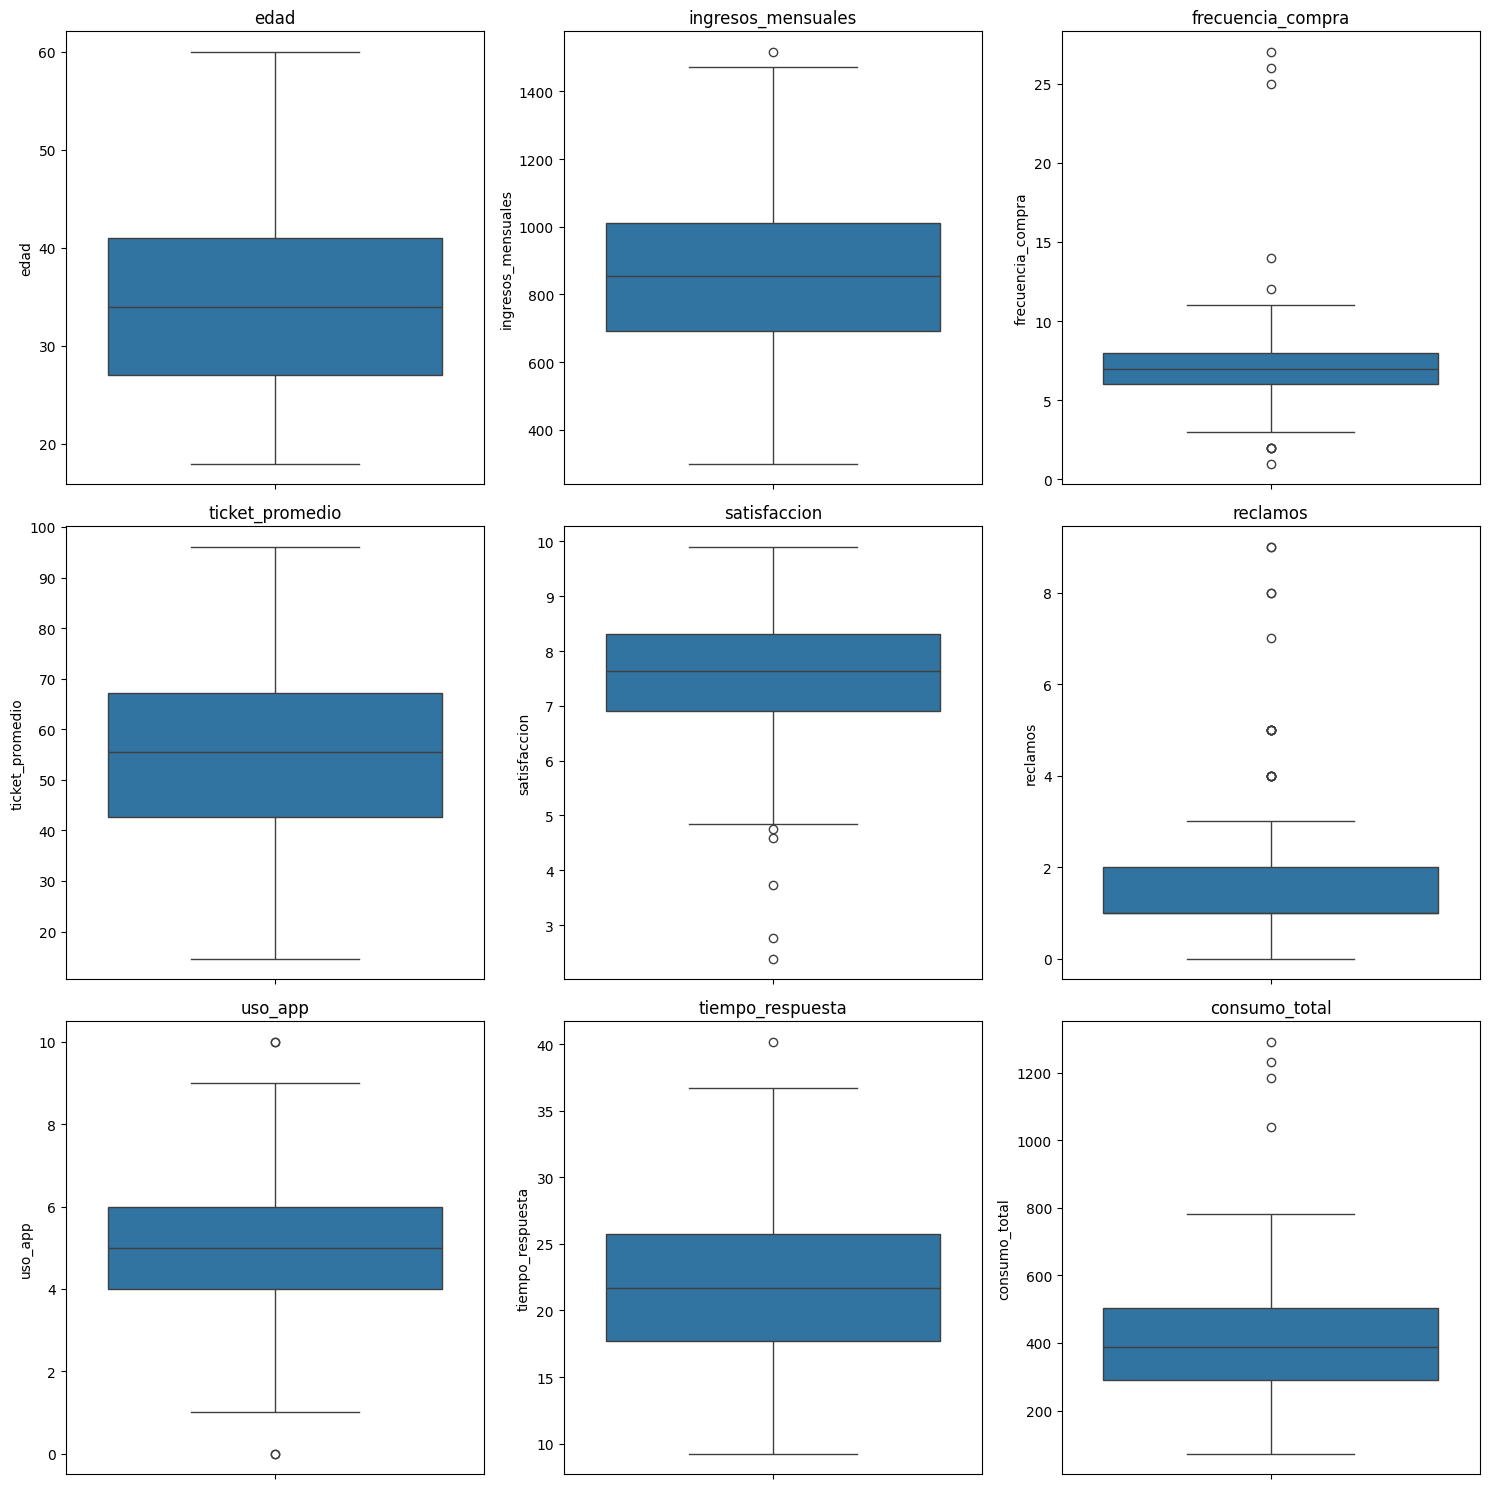

In [24]:
#revision de colores atipicos
cantidad = len(variables_numericas.columns)

columnas = 3
filas = math.ceil(cantidad / columnas)

plt.figure(figsize=(15, 5 * filas))

for i, columna in enumerate(variables_numericas.columns, 1):
    plt.subplot(filas, columnas, i)
    sns.boxplot(y=df[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()

In [25]:
#matriz de correlacion
matriz_correlacion = variables_numericas.corr()

matriz_correlacion.round(2)

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.00,-0.01,-0.04,0.13,-0.10,0.05,0.03,0.06,0.06
ingresos_mensuales,-0.01,1.00,0.05,0.56,-0.00,0.03,-0.09,-0.07,0.30
frecuencia_compra,-0.04,0.05,1.00,0.10,0.25,-0.12,0.57,-0.33,0.83
ticket_promedio,0.13,0.56,0.10,1.00,0.07,-0.06,0.01,-0.10,0.55
satisfaccion,-0.10,-0.00,0.25,0.07,1.00,-0.77,0.10,-0.55,0.33
reclamos,0.05,0.03,-0.12,-0.06,-0.77,1.00,0.08,0.47,-0.21
uso_app,0.03,-0.09,0.57,0.01,0.10,0.08,1.00,-0.26,0.54
tiempo_respuesta,0.06,-0.07,-0.33,-0.10,-0.55,0.47,-0.26,1.00,-0.38
consumo_total,0.06,0.30,0.83,0.55,0.33,-0.21,0.54,-0.38,1.00


## Interpretación del coeficiente de correlación

El coeficiente de correlación toma valores entre -1 y 1:

- Valores cercanos a 1 indican correlación positiva fuerte.
- Valores cercanos a -1 indican correlación negativa fuerte.
- Valores cercanos a 0 indican poca o ninguna relación lineal.

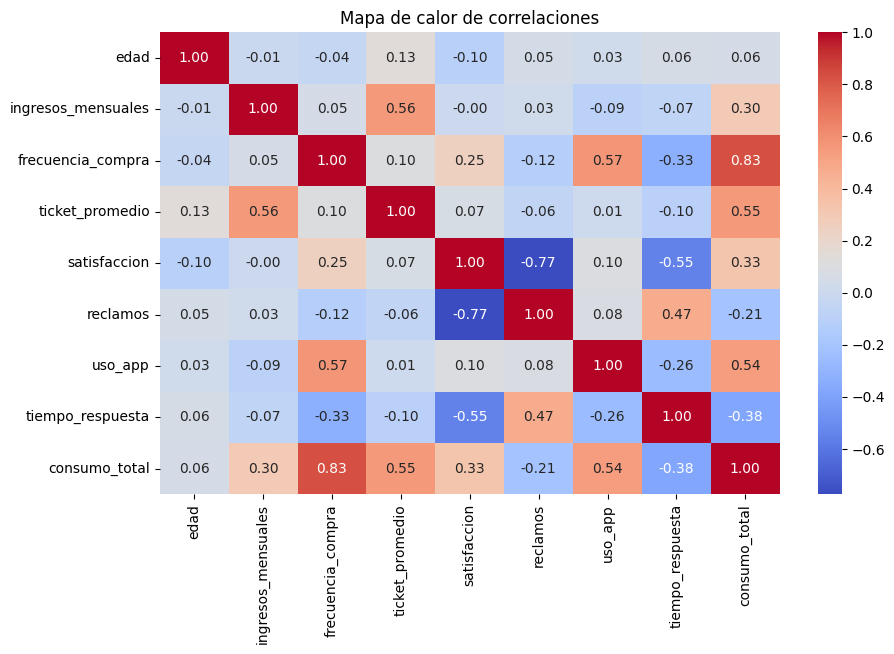

In [26]:
#mapa de calor
plt.figure(figsize=(10,6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de calor de correlaciones")
plt.show()

In [27]:
#identificacion de correlacion positivas importantes
corr = matriz_correlacion.unstack()

corr = corr.sort_values(ascending=False)

corr = corr[corr < 1]

print("Correlaciones positivas más importantes:")
print(corr.head(10))

Correlaciones positivas más importantes:
frecuencia_compra   consumo_total         0.833677
consumo_total       frecuencia_compra     0.833677
frecuencia_compra   uso_app               0.574399
uso_app             frecuencia_compra     0.574399
ticket_promedio     ingresos_mensuales    0.555589
ingresos_mensuales  ticket_promedio       0.555589
consumo_total       ticket_promedio       0.551161
ticket_promedio     consumo_total         0.551161
uso_app             consumo_total         0.542587
consumo_total       uso_app               0.542587
dtype: float64


Las correlaciones positivas más fuertes indican que ambas variables tienden a aumentar juntas.

In [28]:
#correlaciones negativas importantes
print("Correlaciones negativas más importantes:")
print(corr.tail(10))

Correlaciones negativas más importantes:
tiempo_respuesta   uso_app             -0.259140
uso_app            tiempo_respuesta    -0.259140
frecuencia_compra  tiempo_respuesta    -0.331774
tiempo_respuesta   frecuencia_compra   -0.331774
consumo_total      tiempo_respuesta    -0.380181
tiempo_respuesta   consumo_total       -0.380181
                   satisfaccion        -0.546874
satisfaccion       tiempo_respuesta    -0.546874
                   reclamos            -0.773891
reclamos           satisfaccion        -0.773891
dtype: float64


Las correlaciones negativas indican que cuando una variable aumenta, la otra tiende a disminuir.

Interpretación de clusters
Cluster 0

Este grupo presenta los mayores valores promedio en compras, frecuencia y satisfacción. Representa clientes frecuentes y valiosos para la empresa.

Cluster 1

Presenta bajos niveles de compras y frecuencia de uso. Además, la satisfacción es reducida. Este grupo puede representar clientes con riesgo de abandono.

Cluster 2

Muestra valores intermedios en la mayoría de variables. Son clientes con potencial de crecimiento mediante promociones y programas de fidelización.